# ML Assignment 1 - Polynomial Regression

Same plan for both problems, everything scored with **5-fold CV**:

1. **OLS** for every degree, to see roughly which degrees make sense
2. **Ridge (L2)**: coarse sweep over λ, then a fine sweep around the best value
3. **Lasso (L1)**: same coarse → fine idea
4. **Elastic Net**: a small sweep, narrowed down using what Ridge and Lasso found

### Objectives
$Z$ = standardized polynomial features, $n$ = number of training rows.

| Model | Minimise | Solved by |
|---|---|---|
| OLS | $\frac{1}{2n}\lVert y - Z\beta\rVert^2$ | least squares |
| Ridge | $\frac{1}{2n}\lVert y - Z\beta\rVert^2 + \frac{\lambda}{2}\lVert\beta\rVert_2^2$ | closed form: $(Z^\top Z + n\lambda I)\beta = Z^\top y$ |
| Lasso | $\frac{1}{2n}\lVert y - Z\beta\rVert^2 + \alpha\lVert\beta\rVert_1$ | iterative (no closed form) |
| Elastic Net | $\frac{1}{2n}\lVert y - Z\beta\rVert^2 + \alpha\big(\rho\lVert\beta\rVert_1 + \frac{1-\rho}{2}\lVert\beta\rVert_2^2\big)$ | iterative |

Elastic Net with $\rho = 0$ is Ridge, and with $\rho = 1$ it is Lasso.

**Small details that matter**
- **Standardize inside each fold.** Mean/std come from the *training* fold only, otherwise validation data leaks into training. Without scaling, the penalty would hit features like $x^5$ and $x$ very differently.
- **Intercept.** We center $y$ instead of adding a column of ones, so the intercept never gets penalised.
- **The $\frac{1}{n}$ in the loss** makes λ independent of how many rows we train on. So a λ tuned on 800-row folds is still right when we refit on all 1000 rows.
  This also means λ here is a different number from the first notebook, which used $\lVert y - X\beta\rVert^2 + \lambda\lVert\beta\rVert^2$: $\lambda_{\text{here}} = \lambda_{\text{old}} / n$. For example, the old λ = 17 is about 0.021 here.

This notebook is for exploring and choosing models. Writing the prediction CSVs happens later, in the refactored Python code.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from itertools import combinations_with_replacement
from collections import Counter   # only for readable term names
from math import comb              # n-choose-k, for counting terms
from pathlib import Path

torch.set_default_dtype(torch.float64)

# Every plot is also saved as plots/explore_<problem>_<name>.png (for the report).
# "explore_" separates these from the final-model plots that train.py writes.
PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(exist_ok=True)


def save_plot(name):
    # Call right before plt.show(). PROBLEM is set at the start of each problem section.
    plt.savefig(PLOT_DIR / f"explore_{PROBLEM}_{name}.png", dpi=150, bbox_inches="tight")

### Helper functions

In [56]:
def make_polynomial_features(X, degree):
    # All monomials of degree 1..degree (no column of ones, we center y instead)
    n_samples, n_features = X.shape
    features = []
    for d in range(1, degree + 1):
        for combo in combinations_with_replacement(range(n_features), d):
            term = torch.ones(n_samples)
            for idx in combo:
                term = term * X[:, idx]
            features.append(term)
    return torch.stack(features, dim=1)


def term_names(n_features, degree):
    # Readable names in the same column order, e.g. "x1^2·x3"
    names = []
    for d in range(1, degree + 1):
        for combo in combinations_with_replacement(range(n_features), d):
            names.append("·".join(f"x{i+1}" + (f"^{c}" if c > 1 else "")
                                  for i, c in Counter(combo).items()))
    return names


def max_ols_degree(n_features, n_train, limit):
    # Number of terms (including the intercept) for degree d is C(n_features + d, d).
    # Once that exceeds the number of training rows, OLS has infinitely many perfect fits.
    d = 1
    while d < limit and comb(n_features + d + 1, d + 1) <= n_train:
        d += 1
    return d


def standardize(X_train, X_other):
    # Mean/std from the training data only, applied to both
    mean = X_train.mean(dim=0)
    std = X_train.std(dim=0)
    std[std == 0] = 1.0
    return (X_train - mean) / std, (X_other - mean) / std


def mse_r2(y_true, y_pred):
    mse = torch.mean((y_true - y_pred) ** 2)
    r2 = 1 - torch.sum((y_true - y_pred) ** 2) / torch.sum((y_true - y_true.mean()) ** 2)
    return mse.item(), r2.item()


def train_val_split(folds, i):
    val_idx = folds[i]
    train_idx = torch.cat([folds[j] for j in range(len(folds)) if j != i])
    return train_idx, val_idx

### Models

In [57]:
def ols_fit(Z, y):
    return torch.linalg.lstsq(Z, y).solution


def ridge_fit(Z, y, lam):
    n, p = Z.shape
    return torch.linalg.solve(Z.T @ Z + n * lam * torch.eye(p), Z.T @ y)


def soft_threshold(x, t):
    # Shrink every value towards 0 by t, and anything smaller than t becomes exactly 0.
    # This is what makes Lasso coefficients exactly zero.
    return torch.sign(x) * torch.clamp(x.abs() - t, min=0.0)


def enet_fit(Z, y, alpha, rho, beta=None, L=None, n_iter=2000, tol=1e-5):
    """
    Elastic net (rho = 1 gives Lasso) with proximal gradient descent (FISTA).
    Each step: a gradient step on the smooth part (squared loss + L2),
               then soft-threshold for the L1 part.
    beta = starting point. Reusing the answer from a nearby alpha ("warm start")
           makes it converge much faster.
    L    = largest eigenvalue of Z^T Z / n, which sets a safe step size.
    """
    n, p = Z.shape
    if beta is None:
        beta = torch.zeros(p)
    if L is None:
        L = torch.linalg.matrix_norm(Z, 2).item() ** 2 / n

    step = 1.0 / (L + alpha * (1 - rho))
    z, t = beta.clone(), 1.0

    for _ in range(n_iter):
        grad = Z.T @ (Z @ z - y) / n + alpha * (1 - rho) * z
        beta_new = soft_threshold(z - step * grad, step * alpha * rho)

        # momentum: what makes it FISTA instead of plain gradient descent
        t_new = (1 + (1 + 4 * t * t) ** 0.5) / 2
        z = beta_new + ((t - 1) / t_new) * (beta_new - beta)

        converged = (beta_new - beta).abs().max() < tol
        beta, t = beta_new, t_new
        if converged:
            break

    return beta


def enet_final_fit(Z, y, alpha, rho):
    # Used when fitting on all the training data (e.g. to inspect Lasso's coefficients)
    # Walk down from a big alpha to the chosen one (warm starts), keep the last answer
    L = torch.linalg.matrix_norm(Z, 2).item() ** 2 / len(y)
    beta = None
    for a in np.geomspace(max(1.0, alpha), alpha, 15):
        beta = enet_fit(Z, y, a, rho, beta, L)
    return beta

### Cross-validation and sweep helpers

In [58]:
def cv_score(X_poly, y, folds, fit):
    # 5-fold CV for one model. fit(Z, y_centered) must return the coefficients
    fold_mse, fold_r2 = [], []
    for i in range(len(folds)):
        train_idx, val_idx = train_val_split(folds, i)
        Z_train, Z_val = standardize(X_poly[train_idx], X_poly[val_idx])
        y_mean = y[train_idx].mean()

        beta = fit(Z_train, y[train_idx] - y_mean)
        mse, r2 = mse_r2(y[val_idx], Z_val @ beta + y_mean)
        fold_mse.append(mse)
        fold_r2.append(r2)

    return np.mean(fold_mse), np.mean(fold_r2)


def cv_path(X_poly, y, folds, alphas, rho):
    # 5-fold CV for Lasso / Elastic Net over many alphas.
    # Alphas go from large to small so every fit warm-starts from the previous one.
    alphas = sorted(alphas, reverse=True)
    mse = {a: [] for a in alphas}
    r2 = {a: [] for a in alphas}

    for i in range(len(folds)):
        train_idx, val_idx = train_val_split(folds, i)
        Z_train, Z_val = standardize(X_poly[train_idx], X_poly[val_idx])
        y_mean = y[train_idx].mean()
        L = torch.linalg.matrix_norm(Z_train, 2).item() ** 2 / len(train_idx)

        beta = None
        for a in alphas:
            beta = enet_fit(Z_train, y[train_idx] - y_mean, a, rho, beta, L)
            m, r = mse_r2(y[val_idx], Z_val @ beta + y_mean)
            mse[a].append(m)
            r2[a].append(r)

    return {a: (np.mean(mse[a]), np.mean(r2[a])) for a in alphas}


def fine_grid(coarse, best, n=9):
    # Zoom in between the neighbours of the best coarse value
    # (like going 0.1, 1, 10, 30  ->  10, 15, 20, 25, 30)
    coarse = sorted(coarse)
    i = coarse.index(best)
    if i == 0 or i == len(coarse) - 1:
        print("WARNING: best value is at the edge of the coarse grid, consider extending it")
    lo, hi = coarse[max(i - 1, 0)], coarse[min(i + 1, len(coarse) - 1)]
    return list(np.linspace(lo, hi, n))


def best_of(results):
    # results[(degree, value)] = (mse, r2)  ->  key with the lowest MSE
    return min(results, key=lambda k: results[k][0])


def plot_sweep(results, xlabel, title, name):
    # One line per degree: CV MSE vs lambda / alpha
    degrees = sorted({d for d, _ in results})
    plt.figure(figsize=(8, 4))
    for d in degrees:
        xs = sorted(v for dd, v in results if dd == d)
        plt.plot(xs, [results[(d, v)][0] for v in xs], marker="o", label=f"degree {d}")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("CV MSE (log)")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True, which="both", alpha=0.3)
    save_plot(name)
    plt.show()


def plot_fine(results, xlabel, title, name):
    # Fine sweep at one degree: CV MSE vs lambda / alpha (normal axes, the range is small)
    xs = sorted(v for _, v in results)
    d = next(iter(results))[0]
    plt.figure(figsize=(7, 3.5))
    plt.plot(xs, [results[(d, v)][0] for v in xs], marker="o")
    plt.xlabel(xlabel)
    plt.ylabel("CV MSE")
    plt.title(title)
    plt.grid(True)
    save_plot(name)
    plt.show()


def fit_full(X_poly, y, fit):
    # Fit on ALL training rows (scaler included) and return the coefficients
    Z, _ = standardize(X_poly, X_poly)
    return fit(Z, y - y.mean())

In [59]:
# Coarse grids: a 1-3-10 pattern over several orders of magnitude.
# Shared by both problems. The fine grids are built automatically from the results.
COARSE = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]

# Elastic net only needs the in-between rho values: rho = 0 (Ridge) and 1 (Lasso) are done already
EN_RHOS = [0.25, 0.5, 0.75]

---
## Problem 1

### Look at data

In [60]:
PROBLEM = "var1"      # used in saved plot names
train_df = pd.read_csv("dataset/IMT2024008_train_var1.csv")
features = [c for c in train_df.columns if c != "y"]

print(train_df.head())
print(train_df.shape)
print(train_df.describe())
print(train_df.isnull().sum())

# Many inputs sit exactly at -1 or +1 (they look clipped)
print("\nfraction of values exactly at ±1:")
print((train_df[features].abs() == 1).mean().round(3))

         x1        x2        x3        x4        x5        x6         y
0 -1.000000 -0.138987  0.230591 -0.613385  1.000000  0.208709  3.392852
1 -0.729694 -0.043126 -1.000000 -0.595248 -1.000000 -1.000000  1.390434
2  0.809151  0.336482 -1.000000  0.417059  0.792263  0.414750 -1.186098
3  0.056882  0.117577  1.000000  0.788831  0.771625  0.145547 -1.617672
4 -1.000000 -0.390714 -0.851751 -0.979304  1.000000 -0.722259  3.974056
(1000, 7)
                x1           x2           x3           x4           x5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     -0.002051    -0.029475    -0.008323     0.002443    -0.026772   
std       0.720297     0.705564     0.720476     0.719721     0.727409   
min      -1.000000    -1.000000    -1.000000    -1.000000    -1.000000   
25%      -0.678928    -0.665192    -0.734847    -0.692571    -0.719504   
50%      -0.012104    -0.038626     0.025034     0.011309    -0.073907   
75%       0.676782     0.590488     0.65

A lot of inputs sit exactly on the edge (±1). At those points $x^k = \pm 1$ for every power, so high-degree terms never shrink there. That's one reason high degrees get unstable.

### Separate x and y and make 5-fold split

In [61]:
X = torch.tensor(train_df[features].values)
y = torch.tensor(train_df["y"].values)
n_features = X.shape[1]

torch.manual_seed(42)
folds = torch.chunk(torch.randperm(len(X)), 5)
n_train = len(X) - len(folds[0])          # rows used for training in each fold

LIMIT = 10           # max degree allowed by the problem statement
# Last degree where #terms <= #training rows (used for the regularized sweeps)
MAX_DEG = max_ols_degree(n_features, n_train, limit=LIMIT)

print("X:", X.shape, "| y:", y.shape, "| training rows per fold:", n_train)
for d in range(1, LIMIT + 1):
    flag = "  <- more terms than training rows" if comb(n_features + d, d) > n_train else ""
    print(f"degree {d:2d}: {comb(n_features + d, d):5d} terms (incl. intercept){flag}")
print("-> cutoff degree:", MAX_DEG)

X: torch.Size([1000, 6]) | y: torch.Size([1000]) | training rows per fold: 800
degree  1:     7 terms (incl. intercept)
degree  2:    28 terms (incl. intercept)
degree  3:    84 terms (incl. intercept)
degree  4:   210 terms (incl. intercept)
degree  5:   462 terms (incl. intercept)
degree  6:   924 terms (incl. intercept)  <- more terms than training rows
degree  7:  1716 terms (incl. intercept)  <- more terms than training rows
degree  8:  3003 terms (incl. intercept)  <- more terms than training rows
degree  9:  5005 terms (incl. intercept)  <- more terms than training rows
degree 10:  8008 terms (incl. intercept)  <- more terms than training rows
-> cutoff degree: 5


**The cutoff.** Past MAX_DEG there are more terms than training rows, so OLS can fit the training data perfectly in infinitely many ways and its validation error explodes.
OLS below is still run for **every** degree up to the problem's limit, so the plot shows this happening. The dashed line marks the cutoff.
Here degree 6 has 924 terms vs 800 rows, which is the big spike in the plot.
After the spike the error comes back *down* a bit for degrees 7–10. That's called *double descent*: with far more terms than rows, `lstsq` picks the smallest exact fit, which happens to generalise a little better. It's interesting, but it's never close to the regularized models.

The Ridge/Lasso sweeps stop at the cutoff (degree 5). Ridge *could* technically go past it, but degree 10 has 8000+ terms, which makes it very slow. And the first notebook's Ridge sweep up to degree 10 already showed degree 5 was best.

### OLS for every degree

Degree  1 (   6 features): MSE = 8.9378, R² = 0.0889
Degree  2 (  27 features): MSE = 3.2596, R² = 0.6681
Degree  3 (  83 features): MSE = 0.9797, R² = 0.9001
Degree  4 ( 209 features): MSE = 0.7801, R² = 0.9209
Degree  5 ( 461 features): MSE = 1.8267, R² = 0.8147
Degree  6 ( 923 features): MSE = 98.5969, R² = -9.0515
Degree  7 (1715 features): MSE = 8.8580, R² = 0.1006
Degree  8 (3002 features): MSE = 4.7155, R² = 0.5203
Degree  9 (5004 features): MSE = 4.0845, R² = 0.5850
Degree 10 (8007 features): MSE = 3.8139, R² = 0.6107

Best OLS degree (up to the cutoff): 4


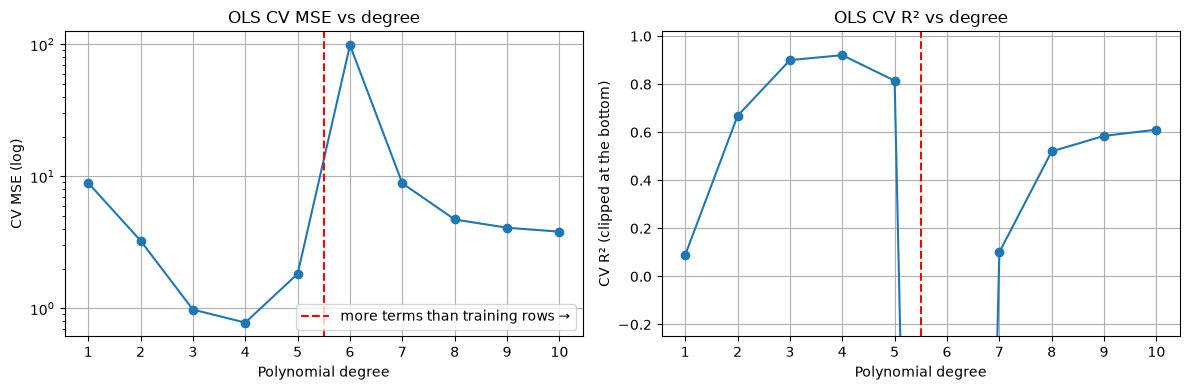

In [62]:
ols_results = {}

for degree in range(1, LIMIT + 1):          # every degree, even past the cutoff
    X_poly = make_polynomial_features(X, degree)
    mse, r2 = cv_score(X_poly, y, folds, ols_fit)
    ols_results[degree] = (mse, r2)
    print(f"Degree {degree:2d} ({X_poly.shape[1]:4d} features): MSE = {mse:.4f}, R² = {r2:.4f}")

# Only trust degrees up to the cutoff when picking the best one
ols_deg = min(range(1, MAX_DEG + 1), key=lambda d: ols_results[d][0])
print("\nBest OLS degree (up to the cutoff):", ols_deg)

degrees = list(ols_results)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(degrees, [ols_results[d][0] for d in degrees], marker="o")
ax[0].set_yscale("log")
ax[0].set_ylabel("CV MSE (log)")
ax[0].set_title("OLS CV MSE vs degree")

ax[1].plot(degrees, [ols_results[d][1] for d in degrees], marker="o")
ax[1].set_ylim(max(min(v[1] for v in ols_results.values()), -0.2) - 0.05, 1.02)   # R² can go hugely negative
ax[1].set_ylabel("CV R² (clipped at the bottom)")
ax[1].set_title("OLS CV R² vs degree")

for a in ax:
    a.axvline(MAX_DEG + 0.5, color="red", linestyle="--", label="more terms than training rows →")
    a.set_xlabel("Polynomial degree")
    a.set_xticks(degrees)
    a.grid(True)
ax[0].legend()
plt.tight_layout()
save_plot("ols_degree")
plt.show()

### Ridge (L2): coarse sweep
Every degree × every λ in the coarse grid. Ridge has a closed form, so this is fast.

Degree  1: best λ = 0.03, MSE = 8.9359
Degree  2: best λ = 0.003, MSE = 3.2590
Degree  3: best λ = 0.01, MSE = 0.9742
Degree  4: best λ = 0.03, MSE = 0.7153
Degree  5: best λ = 0.03, MSE = 0.4708

Best coarse Ridge: degree 5, λ = 0.03


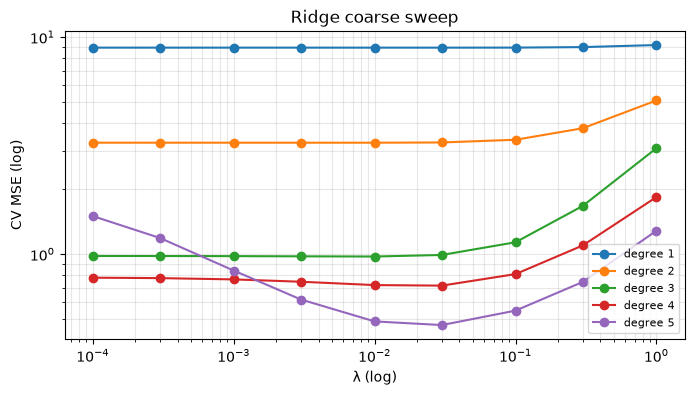

In [63]:
ridge_coarse = {}

for degree in range(1, MAX_DEG + 1):
    X_poly = make_polynomial_features(X, degree)
    for lam in COARSE:
        ridge_coarse[(degree, lam)] = cv_score(X_poly, y, folds,
                                               lambda Z, yc: ridge_fit(Z, yc, lam))
    d, l = best_of({k: v for k, v in ridge_coarse.items() if k[0] == degree})
    print(f"Degree {degree:2d}: best λ = {l:g}, MSE = {ridge_coarse[(d, l)][0]:.4f}")

ridge_deg, ridge_lam_coarse = best_of(ridge_coarse)
print(f"\nBest coarse Ridge: degree {ridge_deg}, λ = {ridge_lam_coarse:g}")
plot_sweep(ridge_coarse, "λ (log)", "Ridge coarse sweep", "ridge_coarse")

How to read these: on the **left** (tiny λ), Ridge is almost OLS, so high degrees overfit. Moving **right**, more shrinkage helps until it starts underfitting. The best spot is in between.

### Ridge (L2): fine sweep
Keep the best degree and zoom in between the two coarse λ values around the best one.

λ = 0.01000: MSE = 0.4893, R² = 0.9504
λ = 0.02125: MSE = 0.4673, R² = 0.9525
λ = 0.03250: MSE = 0.4727, R² = 0.9519
λ = 0.04375: MSE = 0.4839, R² = 0.9508
λ = 0.05500: MSE = 0.4967, R² = 0.9495
λ = 0.06625: MSE = 0.5098, R² = 0.9481
λ = 0.07750: MSE = 0.5230, R² = 0.9468
λ = 0.08875: MSE = 0.5359, R² = 0.9455
λ = 0.10000: MSE = 0.5486, R² = 0.9442

Best Ridge: degree 5, λ = 0.02125, MSE = 0.4673, R² = 0.9525


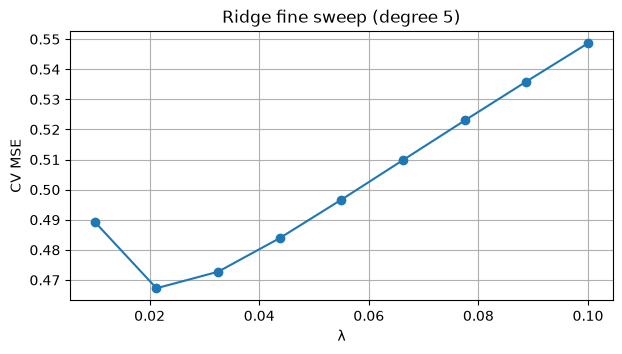

In [64]:
X_poly = make_polynomial_features(X, ridge_deg)
ridge_fine = {}

for lam in fine_grid(COARSE, ridge_lam_coarse):
    ridge_fine[(ridge_deg, lam)] = cv_score(X_poly, y, folds,
                                            lambda Z, yc: ridge_fit(Z, yc, lam))
    print(f"λ = {lam:.5f}: MSE = {ridge_fine[(ridge_deg, lam)][0]:.4f}, R² = {ridge_fine[(ridge_deg, lam)][1]:.4f}")

_, ridge_lam = best_of(ridge_fine)
ridge_mse, ridge_r2 = ridge_fine[(ridge_deg, ridge_lam)]
print(f"\nBest Ridge: degree {ridge_deg}, λ = {ridge_lam:.5f}, MSE = {ridge_mse:.4f}, R² = {ridge_r2:.4f}")
plot_fine(ridge_fine, "λ", f"Ridge fine sweep (degree {ridge_deg})", "ridge_fine")

### Lasso (L1): coarse sweep
$|\beta|$ has a corner at 0, so we can't just set the gradient to zero like for Ridge, and there's no closed form. `enet_fit` with ρ = 1 solves it by repeating two steps:
1. **gradient step** on the squared error (like ordinary gradient descent)
2. **soft-threshold**: $S_t(b) = \mathrm{sign}(b)\,\max(|b| - t,\ 0)$. Every coefficient moves $t$ closer to 0, and the small ones land **exactly** on 0.

Iterating makes it slower than Ridge. To save time, alphas go from big to small, and each fit starts from the previous answer (**warm start**).
At a very big α every coefficient is 0. As α shrinks, terms "switch on" one by one.

Degree  1: best α = 0.0003, MSE = 8.9378
Degree  2: best α = 0.01, MSE = 3.2553
Degree  3: best α = 0.003, MSE = 0.9662
Degree  4: best α = 0.01, MSE = 0.6493
Degree  5: best α = 0.01, MSE = 0.3472

Best coarse Lasso: degree 5, α = 0.01


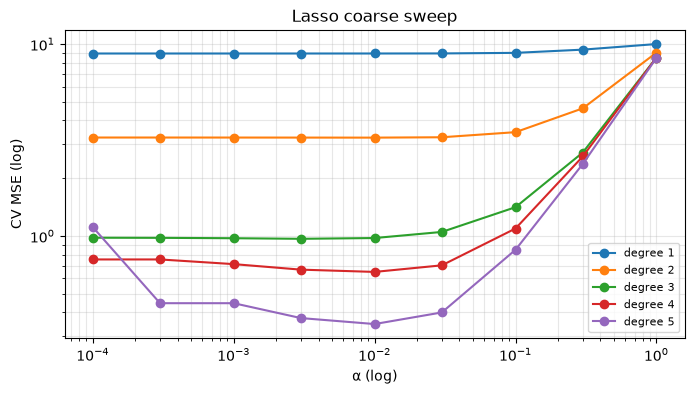

In [65]:
lasso_coarse = {}

for degree in range(1, MAX_DEG + 1):
    X_poly = make_polynomial_features(X, degree)
    path = cv_path(X_poly, y, folds, COARSE, rho=1.0)
    for a, res in path.items():
        lasso_coarse[(degree, a)] = res
    a_best = min(path, key=lambda a: path[a][0])
    print(f"Degree {degree:2d}: best α = {a_best:g}, MSE = {path[a_best][0]:.4f}")

lasso_deg, lasso_alpha_coarse = best_of(lasso_coarse)
print(f"\nBest coarse Lasso: degree {lasso_deg}, α = {lasso_alpha_coarse:g}")
plot_sweep(lasso_coarse, "α (log)", "Lasso coarse sweep", "lasso_coarse")

### Lasso (L1): fine sweep

α = 0.00300: MSE = 0.3730, R² = 0.9621
α = 0.00638: MSE = 0.3528, R² = 0.9641
α = 0.00975: MSE = 0.3473, R² = 0.9647
α = 0.01313: MSE = 0.3482, R² = 0.9646
α = 0.01650: MSE = 0.3543, R² = 0.9640
α = 0.01988: MSE = 0.3633, R² = 0.9630
α = 0.02325: MSE = 0.3743, R² = 0.9619
α = 0.02662: MSE = 0.3861, R² = 0.9607
α = 0.03000: MSE = 0.3992, R² = 0.9594

Best Lasso: degree 5, α = 0.00975, MSE = 0.3473, R² = 0.9647


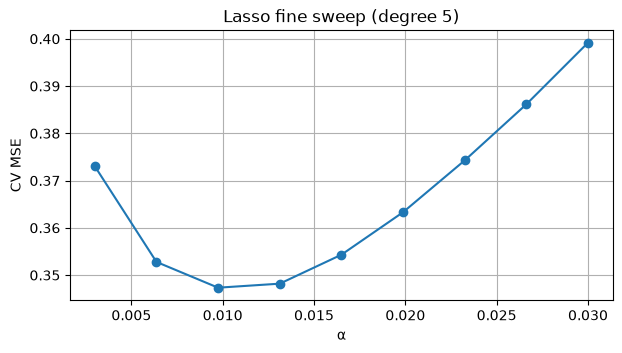

In [66]:
X_poly = make_polynomial_features(X, lasso_deg)
path = cv_path(X_poly, y, folds, fine_grid(COARSE, lasso_alpha_coarse), rho=1.0)
lasso_fine = {(lasso_deg, a): res for a, res in path.items()}

for a in sorted(path):
    print(f"α = {a:.5f}: MSE = {path[a][0]:.4f}, R² = {path[a][1]:.4f}")

_, lasso_alpha = best_of(lasso_fine)
lasso_mse, lasso_r2 = lasso_fine[(lasso_deg, lasso_alpha)]
print(f"\nBest Lasso: degree {lasso_deg}, α = {lasso_alpha:.5f}, MSE = {lasso_mse:.4f}, R² = {lasso_r2:.4f}")
plot_fine(lasso_fine, "α", f"Lasso fine sweep (degree {lasso_deg})", "lasso_fine")

### Which terms does Lasso keep?
Every column is one possible monomial (x1·x5, x2³·x3, …). The true formula behind the data probably uses only some of them. A coefficient of exactly 0 just means **"this term isn't in the formula"**.
- **Ridge** can only shrink coefficients, never remove them, so it gives every term a small weight. Each of those small weights partly fits noise.
- **Lasso** drops the useless terms completely.

If Lasso throws away many terms *and* still beats Ridge on CV, the true polynomial is **sparse**. Removing terms makes the model *simpler*, which is the opposite of overfitting. And the CV score is measured on rows the model never saw, so a better CV score can't come from overfitting.

Lasso keeps 118 of 461 terms (Ridge keeps all 461)

Biggest Lasso terms (standardized scale, so sizes are comparable):
  x1·x5            -1.218
  x3·x6            -0.927
  x2^3·x3          -0.897
  x3^3·x6^2        -0.767
  x6^2             +0.727
  x2·x6            +0.597
  x2^2·x4^2·x5     -0.549
  x2·x4·x6         -0.540
  x4^2·x5^2        +0.486
  x3^2·x4^2        -0.450


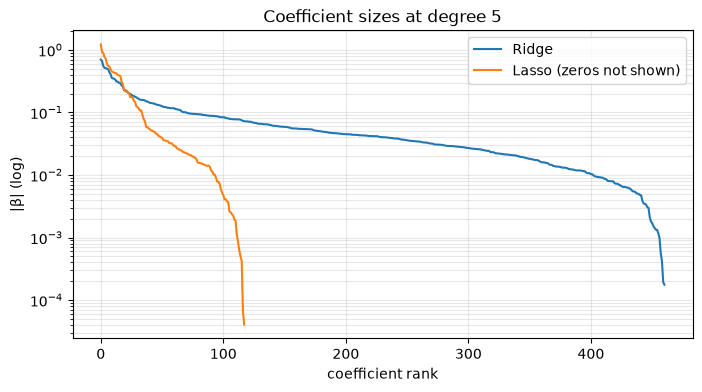

In [67]:
X_poly = make_polynomial_features(X, lasso_deg)
names = term_names(n_features, lasso_deg)

# Ridge at the same degree (its best λ for this degree) vs Lasso
ridge_all = {**ridge_coarse, **ridge_fine}
_, lam_here = best_of({k: v for k, v in ridge_all.items() if k[0] == lasso_deg})
beta_ridge = fit_full(X_poly, y, lambda Z, yc: ridge_fit(Z, yc, lam_here))
beta_lasso = fit_full(X_poly, y, lambda Z, yc: enet_final_fit(Z, yc, lasso_alpha, 1.0))

print(f"Lasso keeps {(beta_lasso != 0).sum().item()} of {len(beta_lasso)} terms "
      f"(Ridge keeps all {len(beta_ridge)})\n")
print("Biggest Lasso terms (standardized scale, so sizes are comparable):")
for i in torch.argsort(beta_lasso.abs(), descending=True)[:10]:
    print(f"  {names[i]:<16} {beta_lasso[i].item():+.3f}")

# Sorted |coefficient| sizes: the Lasso line stops where coefficients become exactly 0
plt.figure(figsize=(8, 4))
plt.semilogy(np.sort(beta_ridge.abs().numpy())[::-1], label="Ridge")
lasso_sorted = np.sort(beta_lasso.abs().numpy())[::-1]
plt.semilogy(lasso_sorted[lasso_sorted > 0], label="Lasso (zeros not shown)")
plt.xlabel("coefficient rank")
plt.ylabel("|β| (log)")
plt.title(f"Coefficient sizes at degree {lasso_deg}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
save_plot("ridge_vs_lasso_coefs")
plt.show()

### Elastic Net: narrowed sweep
A full grid (every degree × every ρ × every α) is what took too long before. So we **use what Ridge and Lasso already told us**:
- **degrees:** only the best Ridge and best Lasso degree
- **ρ:** only 0.25 / 0.5 / 0.75 (ρ = 0 and ρ = 1 are exactly the Ridge and Lasso we just ran)
- **α:** a window around the best Ridge λ and best Lasso α

Narrowing the search in stages like this is a common practical approach. The catch: if the true best sits far outside the window you'd miss it. So check that the best α isn't at the edge of the window.

In [68]:
EN_DEGREES = sorted({ridge_deg, lasso_deg})
lo, hi = min(ridge_lam, lasso_alpha), max(ridge_lam, lasso_alpha)
EN_ALPHAS = list(np.geomspace(hi * 4, lo / 4, 9))
print("degrees:", EN_DEGREES, "| α window:", f"{EN_ALPHAS[-1]:.1e} to {EN_ALPHAS[0]:.1e}")

en_results = {}     # (degree, rho, alpha) -> (mse, r2)
for degree in EN_DEGREES:
    X_poly = make_polynomial_features(X, degree)
    for rho in EN_RHOS:
        path = cv_path(X_poly, y, folds, EN_ALPHAS, rho)
        for a, res in path.items():
            en_results[(degree, rho, a)] = res
        a_best = min(path, key=lambda a: path[a][0])
        edge = "  <- edge of window!" if a_best in (min(EN_ALPHAS), max(EN_ALPHAS)) else ""
        print(f"Degree {degree}, ρ = {rho}: best α = {a_best:.5f}, MSE = {path[a_best][0]:.4f}{edge}")

en_deg, en_rho, en_alpha = min(en_results, key=lambda k: en_results[k][0])
en_mse, en_r2 = en_results[(en_deg, en_rho, en_alpha)]
print(f"\nBest Elastic Net: degree {en_deg}, ρ = {en_rho}, α = {en_alpha:.5f}, MSE = {en_mse:.4f}, R² = {en_r2:.4f}")

degrees: [5] | α window: 2.4e-03 to 8.5e-02
Degree 5, ρ = 0.25: best α = 0.01439, MSE = 0.3832
Degree 5, ρ = 0.5: best α = 0.01439, MSE = 0.3605
Degree 5, ρ = 0.75: best α = 0.01439, MSE = 0.3525

Best Elastic Net: degree 5, ρ = 0.75, α = 0.01439, MSE = 0.3525, R² = 0.9641


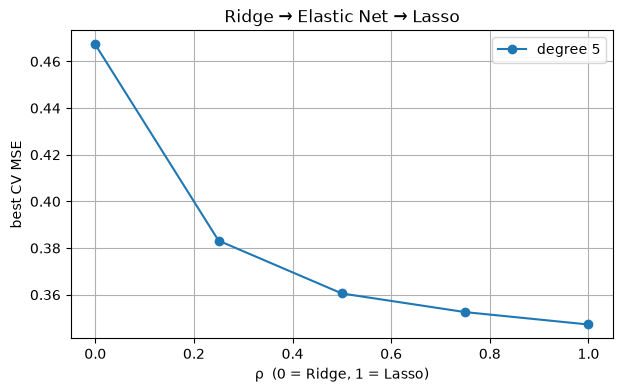

In [69]:
# Best CV MSE vs rho: rho = 0 (Ridge) and rho = 1 (Lasso) come from the sweeps above
ridge_all = {**ridge_coarse, **ridge_fine}
lasso_all = {**lasso_coarse, **lasso_fine}

plt.figure(figsize=(7, 4))
for degree in EN_DEGREES:
    rhos = [0.0] + EN_RHOS + [1.0]
    mses = [min(v[0] for k, v in ridge_all.items() if k[0] == degree)]
    mses += [min(v[0] for k, v in en_results.items() if k[0] == degree and k[1] == r) for r in EN_RHOS]
    mses += [min(v[0] for k, v in lasso_all.items() if k[0] == degree)]
    plt.plot(rhos, mses, marker="o", label=f"degree {degree}")
plt.xlabel("ρ  (0 = Ridge, 1 = Lasso)")
plt.ylabel("best CV MSE")
plt.title("Ridge → Elastic Net → Lasso")
plt.legend()
plt.grid(True)
save_plot("rho")
plt.show()

### Compare
How to judge an MSE number:
- **Against the dumbest baseline:** always predicting the mean of y gives MSE = variance of y.
- **In y's units:** $\sqrt{\text{MSE}}$ is the typical size of an error.
- **Against each other:** if two models are only a few % apart, that's mostly noise from the particular folds, so either is fine. Prefer the simpler one.

The CV MSE is our **estimate of the test MSE**. The real test labels are hidden, so we can't measure test accuracy here.

In [70]:
models = {
    "OLS":        dict(degree=ols_deg,   mse=ols_results[ols_deg][0], r2=ols_results[ols_deg][1]),
    "Ridge":      dict(degree=ridge_deg, lam=ridge_lam,   mse=ridge_mse, r2=ridge_r2),
    "Lasso":      dict(degree=lasso_deg, alpha=lasso_alpha, mse=lasso_mse, r2=lasso_r2),
    "ElasticNet": dict(degree=en_deg, alpha=en_alpha, rho=en_rho, mse=en_mse, r2=en_r2),
}
summary = pd.DataFrame(models).T
summary["rmse"] = np.sqrt(summary["mse"].astype(float))
print(summary)

baseline = y.var().item()
print(f"\nBaseline (always predict the mean): MSE = {baseline:.3f}, RMSE = {baseline ** 0.5:.3f}")
print("Lowest CV MSE:", summary["mse"].astype(float).idxmin())

            degree       mse        r2      lam     alpha   rho      rmse
OLS            4.0  0.780125  0.920884      NaN       NaN   NaN  0.883247
Ridge          5.0  0.467259  0.952535  0.02125       NaN   NaN  0.683563
Lasso          5.0  0.347338  0.964661      NaN  0.009750   NaN  0.589354
ElasticNet     5.0  0.352546  0.964135      NaN  0.014394  0.75  0.593756

Baseline (always predict the mean): MSE = 9.953, RMSE = 3.155
Lowest CV MSE: Lasso


---
## Problem 2

### Look at data

In [71]:
PROBLEM = "var2"      # used in saved plot names
train_df = pd.read_csv("dataset/IMT2024008_train_var2.csv")
features = [c for c in train_df.columns if c != "y"]

print(train_df.head())
print(train_df.shape)
print(train_df.describe())
print(train_df.isnull().sum())

# Many inputs sit exactly at -1 or +1 (they look clipped)
print("\nfraction of values exactly at ±1:")
print((train_df[features].abs() == 1).mean().round(3))

         x1        x2        x3          y
0 -1.000000 -0.321239  0.390544  -2.154440
1 -0.076322  1.000000 -0.625310   9.176260
2 -0.251889  0.230861 -0.815463  -1.347132
3 -0.505375 -0.103042 -0.443275  -0.392153
4  1.000000  1.000000 -0.929433  35.770426
(1000, 4)
                x1           x2           x3            y
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.013927     0.005562     0.009501     2.381789
std       0.677484     0.680134     0.676207     6.820441
min      -1.000000    -1.000000    -1.000000   -29.563852
25%      -0.564925    -0.590319    -0.569746    -0.623481
50%       0.046741     0.016935    -0.002584     1.236782
75%       0.599033     0.599313     0.613974     4.988616
max       1.000000     1.000000     1.000000    38.697295
x1    0
x2    0
x3    0
y     0
dtype: int64

fraction of values exactly at ±1:
x1    0.247
x2    0.246
x3    0.238
dtype: float64


A lot of inputs sit exactly on the edge (±1). At those points $x^k = \pm 1$ for every power, so high-degree terms never shrink there. That's one reason high degrees get unstable.

### Separate x and y and make 5-fold split

In [72]:
X = torch.tensor(train_df[features].values)
y = torch.tensor(train_df["y"].values)
n_features = X.shape[1]

torch.manual_seed(42)
folds = torch.chunk(torch.randperm(len(X)), 5)
n_train = len(X) - len(folds[0])          # rows used for training in each fold

LIMIT = 20           # max degree allowed by the problem statement
# Last degree where #terms <= #training rows (used for the regularized sweeps)
MAX_DEG = max_ols_degree(n_features, n_train, limit=LIMIT)

print("X:", X.shape, "| y:", y.shape, "| training rows per fold:", n_train)
for d in range(1, LIMIT + 1):
    flag = "  <- more terms than training rows" if comb(n_features + d, d) > n_train else ""
    print(f"degree {d:2d}: {comb(n_features + d, d):5d} terms (incl. intercept){flag}")
print("-> cutoff degree:", MAX_DEG)

X: torch.Size([1000, 3]) | y: torch.Size([1000]) | training rows per fold: 800
degree  1:     4 terms (incl. intercept)
degree  2:    10 terms (incl. intercept)
degree  3:    20 terms (incl. intercept)
degree  4:    35 terms (incl. intercept)
degree  5:    56 terms (incl. intercept)
degree  6:    84 terms (incl. intercept)
degree  7:   120 terms (incl. intercept)
degree  8:   165 terms (incl. intercept)
degree  9:   220 terms (incl. intercept)
degree 10:   286 terms (incl. intercept)
degree 11:   364 terms (incl. intercept)
degree 12:   455 terms (incl. intercept)
degree 13:   560 terms (incl. intercept)
degree 14:   680 terms (incl. intercept)
degree 15:   816 terms (incl. intercept)  <- more terms than training rows
degree 16:   969 terms (incl. intercept)  <- more terms than training rows
degree 17:  1140 terms (incl. intercept)  <- more terms than training rows
degree 18:  1330 terms (incl. intercept)  <- more terms than training rows
degree 19:  1540 terms (incl. intercept)  <- mo

**The cutoff.** Past MAX_DEG there are more terms than training rows, so OLS can fit the training data perfectly in infinitely many ways and its validation error explodes.
OLS below is still run for **every** degree up to the problem's limit, so the plot shows this happening. The dashed line marks the cutoff.
Here degree 15 has 816 terms vs 800 rows. Degrees 15–20 explode (MSE in the billions), so the Ridge/Lasso sweeps stop at 14. The regularized error is already flat for degrees 10–14, so nothing suggests going higher would help.

### OLS for every degree

Degree  1 (   3 features): MSE = 32.7003, R² = 0.2945
Degree  2 (   9 features): MSE = 21.1566, R² = 0.5441
Degree  3 (  19 features): MSE = 11.0964, R² = 0.7571
Degree  4 (  34 features): MSE = 3.6600, R² = 0.9207
Degree  5 (  55 features): MSE = 1.4709, R² = 0.9675
Degree  6 (  83 features): MSE = 0.5234, R² = 0.9885
Degree  7 ( 119 features): MSE = 0.3196, R² = 0.9929
Degree  8 ( 164 features): MSE = 0.2584, R² = 0.9943
Degree  9 ( 219 features): MSE = 0.3078, R² = 0.9931
Degree 10 ( 285 features): MSE = 0.3617, R² = 0.9920
Degree 11 ( 363 features): MSE = 0.7011, R² = 0.9834
Degree 12 ( 454 features): MSE = 1.6472, R² = 0.9621
Degree 13 ( 559 features): MSE = 4.8856, R² = 0.8868
Degree 14 ( 679 features): MSE = 111.0477, R² = -1.4008
Degree 15 ( 815 features): MSE = 28080325980.3259, R² = -622136710.3206
Degree 16 ( 968 features): MSE = 373670426114.8656, R² = -10242524485.1988
Degree 17 (1139 features): MSE = 2780871348012.2100, R² = -62696384823.0201
Degree 18 (1329 features): MS

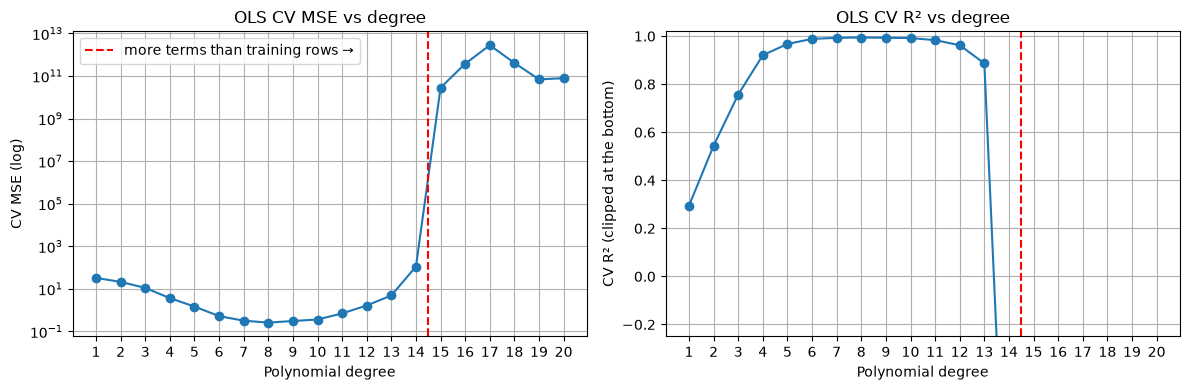

In [73]:
ols_results = {}

for degree in range(1, LIMIT + 1):          # every degree, even past the cutoff
    X_poly = make_polynomial_features(X, degree)
    mse, r2 = cv_score(X_poly, y, folds, ols_fit)
    ols_results[degree] = (mse, r2)
    print(f"Degree {degree:2d} ({X_poly.shape[1]:4d} features): MSE = {mse:.4f}, R² = {r2:.4f}")

# Only trust degrees up to the cutoff when picking the best one
ols_deg = min(range(1, MAX_DEG + 1), key=lambda d: ols_results[d][0])
print("\nBest OLS degree (up to the cutoff):", ols_deg)

degrees = list(ols_results)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(degrees, [ols_results[d][0] for d in degrees], marker="o")
ax[0].set_yscale("log")
ax[0].set_ylabel("CV MSE (log)")
ax[0].set_title("OLS CV MSE vs degree")

ax[1].plot(degrees, [ols_results[d][1] for d in degrees], marker="o")
ax[1].set_ylim(max(min(v[1] for v in ols_results.values()), -0.2) - 0.05, 1.02)   # R² can go hugely negative
ax[1].set_ylabel("CV R² (clipped at the bottom)")
ax[1].set_title("OLS CV R² vs degree")

for a in ax:
    a.axvline(MAX_DEG + 0.5, color="red", linestyle="--", label="more terms than training rows →")
    a.set_xlabel("Polynomial degree")
    a.set_xticks(degrees)
    a.grid(True)
ax[0].legend()
plt.tight_layout()
save_plot("ols_degree")
plt.show()

OLS already gets worse from around degree 11, *before* we run out of rows. High powers like $x^{12}, x^{13}, x^{14}$ look almost the same on $[-1, 1]$ (they're nearly collinear), so the least-squares solution becomes unstable. Ridge fixes exactly this.

### Ridge (L2): coarse sweep
Every degree × every λ in the coarse grid. Ridge has a closed form, so this is fast.

Degree  1: best λ = 0.001, MSE = 32.7002
Degree  2: best λ = 0.001, MSE = 21.1566
Degree  3: best λ = 0.001, MSE = 11.0952
Degree  4: best λ = 0.0003, MSE = 3.6596
Degree  5: best λ = 0.0001, MSE = 1.4708
Degree  6: best λ = 0.0001, MSE = 0.5252
Degree  7: best λ = 0.0001, MSE = 0.3246
Degree  8: best λ = 0.0001, MSE = 0.2492
Degree  9: best λ = 0.0003, MSE = 0.2432
Degree 10: best λ = 0.001, MSE = 0.2370
Degree 11: best λ = 0.003, MSE = 0.2396
Degree 12: best λ = 0.003, MSE = 0.2387
Degree 13: best λ = 0.003, MSE = 0.2464
Degree 14: best λ = 0.003, MSE = 0.2453

Best coarse Ridge: degree 10, λ = 0.001


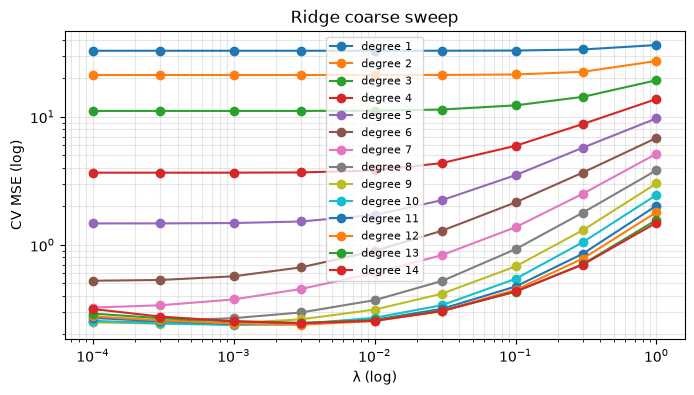

In [74]:
ridge_coarse = {}

for degree in range(1, MAX_DEG + 1):
    X_poly = make_polynomial_features(X, degree)
    for lam in COARSE:
        ridge_coarse[(degree, lam)] = cv_score(X_poly, y, folds,
                                               lambda Z, yc: ridge_fit(Z, yc, lam))
    d, l = best_of({k: v for k, v in ridge_coarse.items() if k[0] == degree})
    print(f"Degree {degree:2d}: best λ = {l:g}, MSE = {ridge_coarse[(d, l)][0]:.4f}")

ridge_deg, ridge_lam_coarse = best_of(ridge_coarse)
print(f"\nBest coarse Ridge: degree {ridge_deg}, λ = {ridge_lam_coarse:g}")
plot_sweep(ridge_coarse, "λ (log)", "Ridge coarse sweep", "ridge_coarse")

How to read these: on the **left** (tiny λ), Ridge is almost OLS, so high degrees overfit. Moving **right**, more shrinkage helps until it starts underfitting. The best spot is in between.

### Ridge (L2): fine sweep
Keep the best degree and zoom in between the two coarse λ values around the best one.

λ = 0.00030: MSE = 0.2439, R² = 0.9947
λ = 0.00064: MSE = 0.2384, R² = 0.9948
λ = 0.00097: MSE = 0.2370, R² = 0.9948
λ = 0.00131: MSE = 0.2371, R² = 0.9948
λ = 0.00165: MSE = 0.2377, R² = 0.9948
λ = 0.00199: MSE = 0.2387, R² = 0.9948
λ = 0.00232: MSE = 0.2398, R² = 0.9948
λ = 0.00266: MSE = 0.2411, R² = 0.9947
λ = 0.00300: MSE = 0.2424, R² = 0.9947

Best Ridge: degree 10, λ = 0.00097, MSE = 0.2370, R² = 0.9948


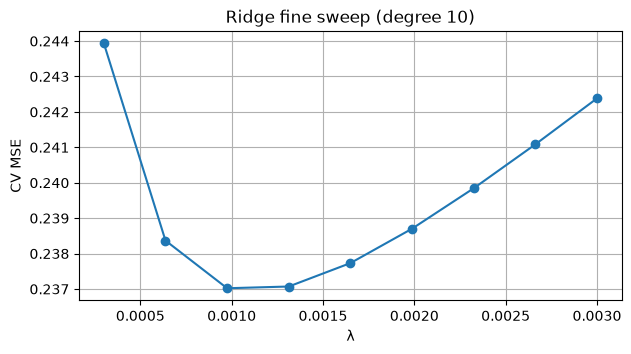

In [75]:
X_poly = make_polynomial_features(X, ridge_deg)
ridge_fine = {}

for lam in fine_grid(COARSE, ridge_lam_coarse):
    ridge_fine[(ridge_deg, lam)] = cv_score(X_poly, y, folds,
                                            lambda Z, yc: ridge_fit(Z, yc, lam))
    print(f"λ = {lam:.5f}: MSE = {ridge_fine[(ridge_deg, lam)][0]:.4f}, R² = {ridge_fine[(ridge_deg, lam)][1]:.4f}")

_, ridge_lam = best_of(ridge_fine)
ridge_mse, ridge_r2 = ridge_fine[(ridge_deg, ridge_lam)]
print(f"\nBest Ridge: degree {ridge_deg}, λ = {ridge_lam:.5f}, MSE = {ridge_mse:.4f}, R² = {ridge_r2:.4f}")
plot_fine(ridge_fine, "λ", f"Ridge fine sweep (degree {ridge_deg})", "ridge_fine")

### Lasso (L1): coarse sweep
$|\beta|$ has a corner at 0, so we can't just set the gradient to zero like for Ridge, and there's no closed form. `enet_fit` with ρ = 1 solves it by repeating two steps:
1. **gradient step** on the squared error (like ordinary gradient descent)
2. **soft-threshold**: $S_t(b) = \mathrm{sign}(b)\,\max(|b| - t,\ 0)$. Every coefficient moves $t$ closer to 0, and the small ones land **exactly** on 0.

Iterating makes it slower than Ridge. To save time, alphas go from big to small, and each fit starts from the previous answer (**warm start**).
At a very big α every coefficient is 0. As α shrinks, terms "switch on" one by one.

Degree  1: best α = 0.0001, MSE = 32.7003
Degree  2: best α = 0.01, MSE = 21.1539
Degree  3: best α = 0.0001, MSE = 11.0964
Degree  4: best α = 0.0001, MSE = 3.6600
Degree  5: best α = 0.0001, MSE = 1.4710
Degree  6: best α = 0.0001, MSE = 0.5233
Degree  7: best α = 0.0001, MSE = 0.3248
Degree  8: best α = 0.0001, MSE = 0.2520
Degree  9: best α = 0.0003, MSE = 0.2467
Degree 10: best α = 0.0003, MSE = 0.2397
Degree 11: best α = 0.0001, MSE = 0.2412
Degree 12: best α = 0.0003, MSE = 0.2409
Degree 13: best α = 0.001, MSE = 0.2453
Degree 14: best α = 0.0003, MSE = 0.2489

Best coarse Lasso: degree 10, α = 0.0003


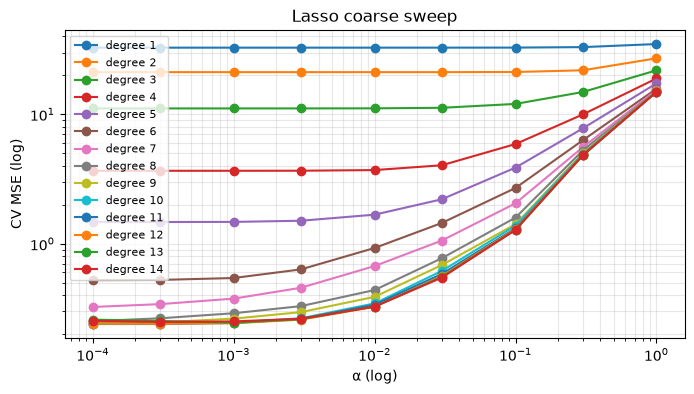

In [76]:
lasso_coarse = {}

for degree in range(1, MAX_DEG + 1):
    X_poly = make_polynomial_features(X, degree)
    path = cv_path(X_poly, y, folds, COARSE, rho=1.0)
    for a, res in path.items():
        lasso_coarse[(degree, a)] = res
    a_best = min(path, key=lambda a: path[a][0])
    print(f"Degree {degree:2d}: best α = {a_best:g}, MSE = {path[a_best][0]:.4f}")

lasso_deg, lasso_alpha_coarse = best_of(lasso_coarse)
print(f"\nBest coarse Lasso: degree {lasso_deg}, α = {lasso_alpha_coarse:g}")
plot_sweep(lasso_coarse, "α (log)", "Lasso coarse sweep", "lasso_coarse")

### Lasso (L1): fine sweep

α = 0.00010: MSE = 0.2438, R² = 0.9947
α = 0.00021: MSE = 0.2405, R² = 0.9948
α = 0.00032: MSE = 0.2409, R² = 0.9948
α = 0.00044: MSE = 0.2427, R² = 0.9947
α = 0.00055: MSE = 0.2432, R² = 0.9947
α = 0.00066: MSE = 0.2431, R² = 0.9947
α = 0.00078: MSE = 0.2462, R² = 0.9946
α = 0.00089: MSE = 0.2466, R² = 0.9946
α = 0.00100: MSE = 0.2466, R² = 0.9946

Best Lasso: degree 10, α = 0.00021, MSE = 0.2405, R² = 0.9948


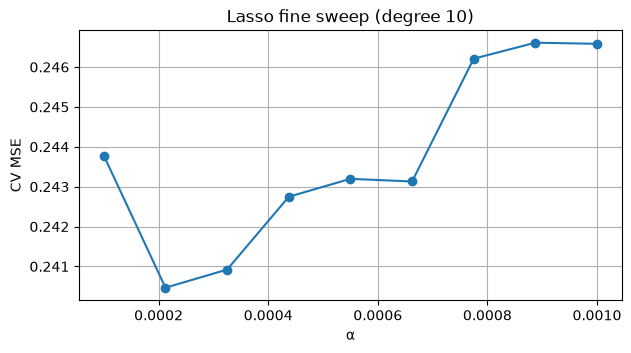

In [77]:
X_poly = make_polynomial_features(X, lasso_deg)
path = cv_path(X_poly, y, folds, fine_grid(COARSE, lasso_alpha_coarse), rho=1.0)
lasso_fine = {(lasso_deg, a): res for a, res in path.items()}

for a in sorted(path):
    print(f"α = {a:.5f}: MSE = {path[a][0]:.4f}, R² = {path[a][1]:.4f}")

_, lasso_alpha = best_of(lasso_fine)
lasso_mse, lasso_r2 = lasso_fine[(lasso_deg, lasso_alpha)]
print(f"\nBest Lasso: degree {lasso_deg}, α = {lasso_alpha:.5f}, MSE = {lasso_mse:.4f}, R² = {lasso_r2:.4f}")
plot_fine(lasso_fine, "α", f"Lasso fine sweep (degree {lasso_deg})", "lasso_fine")

### Which terms does Lasso keep?
Every column is one possible monomial (x1·x5, x2³·x3, …). The true formula behind the data probably uses only some of them. A coefficient of exactly 0 just means **"this term isn't in the formula"**.
- **Ridge** can only shrink coefficients, never remove them, so it gives every term a small weight. Each of those small weights partly fits noise.
- **Lasso** drops the useless terms completely.

If Lasso throws away many terms *and* still beats Ridge on CV, the true polynomial is **sparse**. Removing terms makes the model *simpler*, which is the opposite of overfitting. And the CV score is measured on rows the model never saw, so a better CV score can't come from overfitting.

Lasso keeps 176 of 285 terms (Ridge keeps all 285)

Biggest Lasso terms (standardized scale, so sizes are comparable):
  x2^2·x3^3        +2.245
  x2^6             +1.984
  x1^4·x2^2        +1.509
  x1^7             +1.420
  x2^9             +1.410
  x1·x2            +1.311
  x1·x2^2·x3^4     +1.283
  x1^3·x3          +1.181
  x1               +1.122
  x1^5·x2^4        -1.103


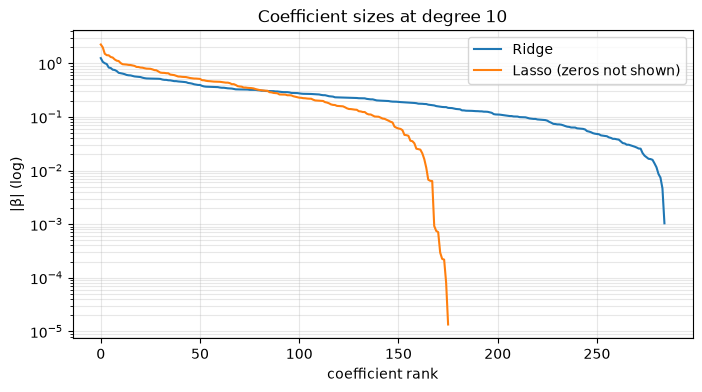

In [78]:
X_poly = make_polynomial_features(X, lasso_deg)
names = term_names(n_features, lasso_deg)

# Ridge at the same degree (its best λ for this degree) vs Lasso
ridge_all = {**ridge_coarse, **ridge_fine}
_, lam_here = best_of({k: v for k, v in ridge_all.items() if k[0] == lasso_deg})
beta_ridge = fit_full(X_poly, y, lambda Z, yc: ridge_fit(Z, yc, lam_here))
beta_lasso = fit_full(X_poly, y, lambda Z, yc: enet_final_fit(Z, yc, lasso_alpha, 1.0))

print(f"Lasso keeps {(beta_lasso != 0).sum().item()} of {len(beta_lasso)} terms "
      f"(Ridge keeps all {len(beta_ridge)})\n")
print("Biggest Lasso terms (standardized scale, so sizes are comparable):")
for i in torch.argsort(beta_lasso.abs(), descending=True)[:10]:
    print(f"  {names[i]:<16} {beta_lasso[i].item():+.3f}")

# Sorted |coefficient| sizes: the Lasso line stops where coefficients become exactly 0
plt.figure(figsize=(8, 4))
plt.semilogy(np.sort(beta_ridge.abs().numpy())[::-1], label="Ridge")
lasso_sorted = np.sort(beta_lasso.abs().numpy())[::-1]
plt.semilogy(lasso_sorted[lasso_sorted > 0], label="Lasso (zeros not shown)")
plt.xlabel("coefficient rank")
plt.ylabel("|β| (log)")
plt.title(f"Coefficient sizes at degree {lasso_deg}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
save_plot("ridge_vs_lasso_coefs")
plt.show()

### Elastic Net: narrowed sweep
A full grid (every degree × every ρ × every α) is what took too long before. So we **use what Ridge and Lasso already told us**:
- **degrees:** only the best Ridge and best Lasso degree
- **ρ:** only 0.25 / 0.5 / 0.75 (ρ = 0 and ρ = 1 are exactly the Ridge and Lasso we just ran)
- **α:** a window around the best Ridge λ and best Lasso α

Narrowing the search in stages like this is a common practical approach. The catch: if the true best sits far outside the window you'd miss it. So check that the best α isn't at the edge of the window.

In [79]:
EN_DEGREES = sorted({ridge_deg, lasso_deg})
lo, hi = min(ridge_lam, lasso_alpha), max(ridge_lam, lasso_alpha)
EN_ALPHAS = list(np.geomspace(hi * 4, lo / 4, 9))
print("degrees:", EN_DEGREES, "| α window:", f"{EN_ALPHAS[-1]:.1e} to {EN_ALPHAS[0]:.1e}")

en_results = {}     # (degree, rho, alpha) -> (mse, r2)
for degree in EN_DEGREES:
    X_poly = make_polynomial_features(X, degree)
    for rho in EN_RHOS:
        path = cv_path(X_poly, y, folds, EN_ALPHAS, rho)
        for a, res in path.items():
            en_results[(degree, rho, a)] = res
        a_best = min(path, key=lambda a: path[a][0])
        edge = "  <- edge of window!" if a_best in (min(EN_ALPHAS), max(EN_ALPHAS)) else ""
        print(f"Degree {degree}, ρ = {rho}: best α = {a_best:.5f}, MSE = {path[a_best][0]:.4f}{edge}")

en_deg, en_rho, en_alpha = min(en_results, key=lambda k: en_results[k][0])
en_mse, en_r2 = en_results[(en_deg, en_rho, en_alpha)]
print(f"\nBest Elastic Net: degree {en_deg}, ρ = {en_rho}, α = {en_alpha:.5f}, MSE = {en_mse:.4f}, R² = {en_r2:.4f}")

degrees: [10] | α window: 5.3e-05 to 3.9e-03
Degree 10, ρ = 0.25: best α = 0.00078, MSE = 0.2388
Degree 10, ρ = 0.5: best α = 0.00046, MSE = 0.2394
Degree 10, ρ = 0.75: best α = 0.00027, MSE = 0.2394

Best Elastic Net: degree 10, ρ = 0.25, α = 0.00078, MSE = 0.2388, R² = 0.9948


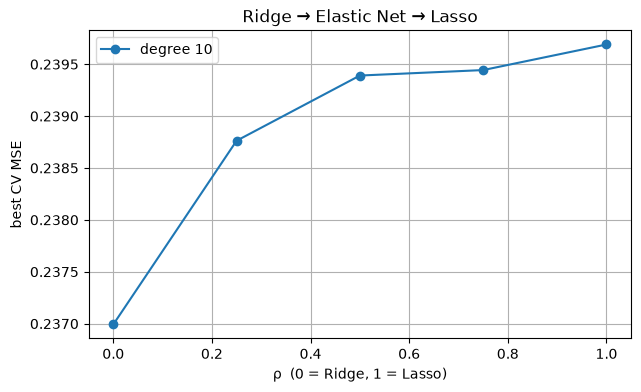

In [80]:
# Best CV MSE vs rho: rho = 0 (Ridge) and rho = 1 (Lasso) come from the sweeps above
ridge_all = {**ridge_coarse, **ridge_fine}
lasso_all = {**lasso_coarse, **lasso_fine}

plt.figure(figsize=(7, 4))
for degree in EN_DEGREES:
    rhos = [0.0] + EN_RHOS + [1.0]
    mses = [min(v[0] for k, v in ridge_all.items() if k[0] == degree)]
    mses += [min(v[0] for k, v in en_results.items() if k[0] == degree and k[1] == r) for r in EN_RHOS]
    mses += [min(v[0] for k, v in lasso_all.items() if k[0] == degree)]
    plt.plot(rhos, mses, marker="o", label=f"degree {degree}")
plt.xlabel("ρ  (0 = Ridge, 1 = Lasso)")
plt.ylabel("best CV MSE")
plt.title("Ridge → Elastic Net → Lasso")
plt.legend()
plt.grid(True)
save_plot("rho")
plt.show()

### Compare
How to judge an MSE number:
- **Against the dumbest baseline:** always predicting the mean of y gives MSE = variance of y.
- **In y's units:** $\sqrt{\text{MSE}}$ is the typical size of an error.
- **Against each other:** if two models are only a few % apart, that's mostly noise from the particular folds, so either is fine. Prefer the simpler one.

The CV MSE is our **estimate of the test MSE**. The real test labels are hidden, so we can't measure test accuracy here.

In [81]:
models = {
    "OLS":        dict(degree=ols_deg,   mse=ols_results[ols_deg][0], r2=ols_results[ols_deg][1]),
    "Ridge":      dict(degree=ridge_deg, lam=ridge_lam,   mse=ridge_mse, r2=ridge_r2),
    "Lasso":      dict(degree=lasso_deg, alpha=lasso_alpha, mse=lasso_mse, r2=lasso_r2),
    "ElasticNet": dict(degree=en_deg, alpha=en_alpha, rho=en_rho, mse=en_mse, r2=en_r2),
}
summary = pd.DataFrame(models).T
summary["rmse"] = np.sqrt(summary["mse"].astype(float))
print(summary)

baseline = y.var().item()
print(f"\nBaseline (always predict the mean): MSE = {baseline:.3f}, RMSE = {baseline ** 0.5:.3f}")
print("Lowest CV MSE:", summary["mse"].astype(float).idxmin())

            degree       mse        r2       lam     alpha   rho      rmse
OLS            8.0  0.258441  0.994328       NaN       NaN   NaN  0.508371
Ridge         10.0  0.237021  0.994840  0.000975       NaN   NaN  0.486848
Lasso         10.0  0.240467  0.994763       NaN  0.000213   NaN  0.490374
ElasticNet    10.0  0.238762  0.994804       NaN  0.000779  0.25  0.488633

Baseline (always predict the mean): MSE = 46.518, RMSE = 6.820
Lowest CV MSE: Ridge
